In [1]:
!pip install transformers

In [2]:
!pip install --upgrade -q transformers
!pip install --upgrade -q tf_keras
!pip install -q Korpora

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 88.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 45.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 45.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 644.9/644.9 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 67.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 644.9/644.9 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 67.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 66.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 66.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-text 2.18.1 requires tensorflow<2.19,>=2.18.0, but you have tensorflow 2.19.0 which is incompatible.
tensorflow-d

### __런타임->세션 다시 시작__

In [3]:
import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'

# 라이브러리 정보 확인

In [4]:
!pip show tensorflow transformers tf_keras

Name: tensorflow
Version: 2.19.0
Summary: TensorFlow is an open source machine learning framework for everyone.
Home-page: https://www.tensorflow.org/
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: /usr/local/lib/python3.11/dist-packages
Requires: absl-py, astunparse, flatbuffers, gast, google-pasta, grpcio, h5py, keras, libclang, ml-dtypes, numpy, opt-einsum, packaging, protobuf, requests, setuptools, six, tensorboard, tensorflow-io-gcs-filesystem, termcolor, typing-extensions, wrapt
Required-by: dopamine_rl, tensorflow-text, tensorflow_decision_forests, tf_keras
---
Name: transformers
Version: 4.52.4
Summary: State-of-the-art Machine Learning for JAX, PyTorch and TensorFlow
Home-page: https://github.com/huggingface/transformers
Author: The Hugging Face team (past and future) with the help of all our contributors (https://github.com/huggingface/transformers/graphs/contributors)
Author-email: transformers@huggingface.co
License: Apache 2.0 Licen

In [5]:
import tensorflow as tf

# Check if TensorFlow is using a GPU.
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

# 데이터 전처리

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import urllib.request
import tensorflow as tf

In [8]:
from Korpora import Korpora
Korpora.fetch(corpus_name='nsmc', root_dir='/content/', force_download=True, )

[nsmc] download ratings_train.txt: 14.6MB [00:00, 188MB/s]
[nsmc] download ratings_test.txt: 4.90MB [00:00, 98.8MB/s]


In [15]:
df = pd.read_csv('/content/drive/MyDrive/디스부_최종프로젝트/labeling.csv', encoding='cp949')

In [16]:
df.head()

,text,label,Unnamed: 2
0,0: Hola. [SEP] 1: hi. [SEP] 1: whats up? [SEP]...,0,NaN
1,0: happy is ayuppie word. [SEP] 0: a yuppie * ...,0,NaN
2,0: hi [SEP] 1: hihi [SEP] 1: m or f?? [SEP] 0:...,0,NaN
3,0: Im a 17 F Lesbian. Im looking for girls onl...,0,NaN
4,0: hey! [SEP] 1: Heyyyy [SEP] 0: whats up [SEP...,0,NaN


In [17]:
len(df)

29618

In [19]:
df.drop(['Unnamed: 2'], axis=1, inplace=True)

In [20]:
df.head()

,text,label
0,0: Hola. [SEP] 1: hi. [SEP] 1: whats up? [SEP]...,0
1,0: happy is ayuppie word. [SEP] 0: a yuppie * ...,0
2,0: hi [SEP] 1: hihi [SEP] 1: m or f?? [SEP] 0:...,0
3,0: Im a 17 F Lesbian. Im looking for girls onl...,0
4,0: hey! [SEP] 1: Heyyyy [SEP] 0: whats up [SEP...,0


In [21]:
from sklearn.model_selection import train_test_split

train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['text'], df['label'],
    test_size=0.2,          # 검증 데이터 비율 (예: 20%)
    random_state=42,        # 재현 가능성을 위한 랜덤 시드
)


In [24]:
print(len(train_texts))
print(len(val_texts))
print(len(train_labels))
print(len(val_labels))

23694
5924
23694
5924


In [79]:
train_data = pd.DataFrame({'text': train_texts, 'label': train_labels})
test_data = pd.DataFrame({'text': val_texts, 'label': val_labels})

In [80]:
train_data['text'].nunique(), train_data['label'].nunique()

(23664, 2)

In [81]:
train_data.drop_duplicates(subset=['text'], inplace=True) # document 열에서 중복인 내용이 있다면 중복 제거

In [82]:
print('총 샘플의 수 :',len(train_data))

총 샘플의 수 : 23665


In [83]:
print('총 샘플의 수 :',len(test_data))

총 샘플의 수 : 5924


<Axes: xlabel='label'>

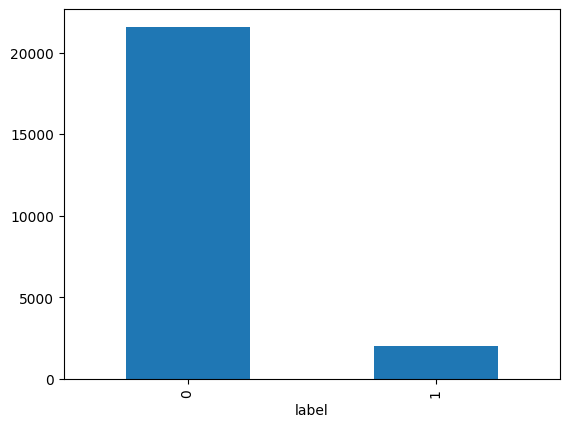

In [84]:
train_data['label'].value_counts().plot(kind = 'bar')

In [85]:
print(train_data.isnull().values.any())

True


In [86]:
print(train_data.isnull().sum())

text      1
label    65
dtype: int64


In [88]:
train_data.loc[train_data.text.isnull()]

,text,label
2001,NaN,0


In [89]:
train_data = train_data.dropna(how = 'any') # Null 값이 존재하는 행 제거
print(train_data.isnull().values.any()) # Null 값이 존재하는지 확인

False


In [90]:
print(len(train_data))

23599


# 토크나이저를 이용한 정수 인코딩

이미 학습해놓은 모델을 사용한다고 하면  

1. 토크나이저 (이 모델이 만들어졌을 당시에 '사과' 라는 단어가 36번이었다. 정보를 알기 위해)  
2. 모델  

이 두 가지를 로드해야 합니다.

In [91]:
import transformers

In [92]:
transformers.__version__

'4.52.4'

In [93]:
from transformers import BertTokenizerFast

tokenizer = BertTokenizerFast.from_pretrained("google-bert/bert-base-uncased")

from transformers import BertTokenizerFast.

tokenizer = BertTokenizerFast.from_pretrained("사용하고자 하는 모델 이름")

from transformers import TFBertForSequenceClassification  
model = TFBertForSequenceClassification.from_pretrained("사용하고자 하는 모델 이름", num_labels=클래스의 수(분류할 종류 개수), from_pt=True)

In [94]:
test_data = test_data.dropna(how = 'any')

In [95]:
print(len(test_data))

5908


In [96]:
X_train_list = train_data['text'].tolist()
X_test_list = test_data['text'].tolist()
y_train = train_data['label'].tolist()
y_test = test_data['label'].tolist()

In [97]:
X_train = tokenizer(X_train_list, truncation=True, padding=True)
X_test = tokenizer(X_test_list, truncation=True, padding=True)

In [98]:
print(X_train[0].tokens)

['[CLS]', '0', ':', 'hey', '[SEP]', '1', ':', 'hi', '[SEP]', '0', ':', 'what', '##s', 'up', '?', '[SEP]', '1', ':', 'cu', '##ul', '[SEP]', '1', ':', 'u', '[SEP]', '0', ':', 'cu', '##ul', '?', '[SEP]', '0', ':', 'what', '##s', 'that', '?', '[SEP]', '1', ':', 'as', '##l', '[SEP]', '0', ':', 'm', '[SEP]', '1', ':', 'am', 'feel', '##in', '##h', 'good', '[SEP]', '0', ':', 'what', '##s', 'your', 'as', '##l', '?', '[SEP]', '1', ':', 'f', '[SEP]', '0', ':', 'cool', '[SEP]', '0', ':', 'where', 'are', 'you', 'from', '?', '[SEP]', '1', ':', 'from', '[SEP]', '1', ':', 'female', '[SEP]', '0', ':', '?', '[SEP]', '0', ':', 'ok', '[SEP]', '1', ':', 'ghana', '[SEP]', '0', ':', 'are', 'you', 'wet', '?', '[SEP]', '1', ':', 'u', '[SEP]', '1', ':', 'y', '?', '?', '?', '[SEP]', '0', ':', 'miami', '[SEP]', '0', ':', 'never', '##mind', '[SEP]', '1', ':', 'name', '[SEP]', '0', ':', 'adrian', '.', 'you', '/', '[SEP]', '1', ':', 'law', '##ren', '##cia', '[SEP]', '0', ':', 'cool', '[SEP]', '0', ':', 'how', 'old',

In [99]:
print(X_train[0].ids)

[101, 1014, 1024, 4931, 102, 1015, 1024, 7632, 102, 1014, 1024, 2054, 2015, 2039, 1029, 102, 1015, 1024, 12731, 5313, 102, 1015, 1024, 1057, 102, 1014, 1024, 12731, 5313, 1029, 102, 1014, 1024, 2054, 2015, 2008, 1029, 102, 1015, 1024, 2004, 2140, 102, 1014, 1024, 1049, 102, 1015, 1024, 2572, 2514, 2378, 2232, 2204, 102, 1014, 1024, 2054, 2015, 2115, 2004, 2140, 1029, 102, 1015, 1024, 1042, 102, 1014, 1024, 4658, 102, 1014, 1024, 2073, 2024, 2017, 2013, 1029, 102, 1015, 1024, 2013, 102, 1015, 1024, 2931, 102, 1014, 1024, 1029, 102, 1014, 1024, 7929, 102, 1015, 1024, 9701, 102, 1014, 1024, 2024, 2017, 4954, 1029, 102, 1015, 1024, 1057, 102, 1015, 1024, 1061, 1029, 1029, 1029, 102, 1014, 1024, 5631, 102, 1014, 1024, 2196, 23356, 102, 1015, 1024, 2171, 102, 1014, 1024, 7918, 1012, 2017, 1013, 102, 1015, 1024, 2375, 7389, 7405, 102, 1014, 1024, 4658, 102, 1014, 1024, 2129, 2214, 2024, 2017, 1029, 102, 1015, 1024, 2322, 102, 1015, 1024, 1057, 102, 1014, 1024, 2385, 1024, 1013, 102, 1015, 102

In [100]:
print(X_train[0].type_ids)

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

type_ids는 지금 풀고자 하는 문제에서 문장의 종류의 개수를 의미하는데, 일반적으로 두 개 이상의 문장을 가지고 푸는 문제일 경우에는 [0, 0, 0, 0, 1, 1, 1, 1] 이런 식의 값이 들어가지만 네이버 영화 리뷰는 문장 1개를 보고 푸는 문제라서 [0, 0, 0, 0, 0, 0, 0, 0]이 들어간다.

In [101]:
print(X_train[0].attention_mask)

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

# 데이터셋 생성 및 모델 학습

In [102]:
import tensorflow as tf

train_dataset = tf.data.Dataset.from_tensor_slices((
    dict(X_train),
    y_train
))

val_dataset = tf.data.Dataset.from_tensor_slices((
    dict(X_test),
    y_test
))

In [103]:
from transformers import TFBertForSequenceClassification
from tensorflow.keras.callbacks import EarlyStopping

In [104]:
num_class = 2

In [105]:
optimizer = tf.keras.optimizers.Adam(learning_rate=5e-5)

In [106]:
model = TFBertForSequenceClassification.from_pretrained("google-bert/bert-base-uncased", num_labels=num_class, from_pt=True)
model.compile(optimizer=optimizer, loss=model.hf_compute_loss, metrics=['accuracy'])

All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [107]:
model.summary()

Model: "tf_bert_for_sequence_classification_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 bert (TFBertMainLayer)      multiple                  109482240 
                                                                 
 dropout_189 (Dropout)       multiple                  0         
                                                                 
 classifier (Dense)          multiple                  1538      
                                                                 
Total params: 109483778 (417.65 MB)
Trainable params: 109483778 (417.65 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [112]:
def convert_label(x, y):
    y = tf.strings.to_number(y, out_type=tf.int32)  # 문자열 → 정수형
    return x, y

train_dataset = train_dataset.map(convert_label)
val_dataset = val_dataset.map(convert_label)

In [114]:
for x_batch, y_batch in train_dataset.take(1):
    print("레이블 데이터 타입:", y_batch.dtype)
    print("레이블 샘플 값:", y_batch.numpy())

레이블 데이터 타입: <dtype: 'int32'>
레이블 샘플 값: 0


In [ ]:
callback_earlystop = EarlyStopping(
    monitor="val_accuracy",
    min_delta=0.001,
    patience=2)

model.fit(
    train_dataset.shuffle(10000).batch(8), epochs=1,
    validation_data = val_dataset.shuffle(10000).batch(16),
    callbacks = [callback_earlystop]
)

 309/2950 [==>...........................] - ETA: 1:29:34 - loss: 0.1230 - accuracy: 0.9551

In [ ]:
model.evaluate(val_dataset.batch(1024))

49/49 [==============================] - 397s 8s/step - loss: 0.2567 - accuracy: 0.8942


[0.2567199766635895, 0.8942136764526367]

# 모델 저장

In [ ]:
model.save_pretrained('nsmc_model/bert-base')
tokenizer.save_pretrained('nsmc_model/bert-base')

('nsmc_model/bert-base/tokenizer_config.json',
 'nsmc_model/bert-base/special_tokens_map.json',
 'nsmc_model/bert-base/vocab.txt',
 'nsmc_model/bert-base/added_tokens.json',
 'nsmc_model/bert-base/tokenizer.json')

# 모델 로드 및 테스트

In [ ]:
from transformers import TextClassificationPipeline

# 로드하기
loaded_tokenizer = BertTokenizerFast.from_pretrained('nsmc_model/bert-base')
loaded_model = TFBertForSequenceClassification.from_pretrained('nsmc_model/bert-base')

text_classifier = TextClassificationPipeline(
    tokenizer=loaded_tokenizer,
    model=loaded_model,
    framework='tf',
    top_k=None,
    return_all_scores=True
)

Some layers from the model checkpoint at nsmc_model/bert-base were not used when initializing TFBertForSequenceClassification: ['dropout_37']
- This IS expected if you are initializing TFBertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
All the layers of TFBertForSequenceClassification were initialized from the model checkpoint at nsmc_model/bert-base.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertForSequenceClassification for predictions without further training.
Device set to use 0


In [ ]:
test_data

,id,document,label
0,6270596,굳 ㅋ,1
1,9274899,GDNTOPCLASSINTHECLUB,0
2,8544678,뭐야 이 평점들은.... 나쁘진 않지만 10점 짜리는 더더욱 아니잖아,0
3,6825595,지루하지는 않은데 완전 막장임... 돈주고 보기에는....,0
4,6723715,3D만 아니었어도 별 다섯 개 줬을텐데.. 왜 3D로 나와서 제 심기를 불편하게 하죠??,0
...,...,...,...
49995,4608761,오랜만에 평점 로긴했네ㅋㅋ 킹왕짱 쌈뽕한 영화를 만났습니다 강렬하게 육쾌함,1
49996,5308387,의지 박약들이나 하는거다 탈영은 일단 주인공 김대희 닮았고 이등병 찐따 OOOO,0
49997,9072549,그림도 좋고 완성도도 높았지만... 보는 내내 불안하게 만든다,0
49998,5802125,절대 봐서는 안 될 영화.. 재미도 없고 기분만 잡치고.. 한 세트장에서 다 해먹네,0


In [ ]:
text_classifier('뭐야 이 평점들은.... 나쁘진 않지만 10점 짜리는 더더욱 아니잖아')[0]

[{'label': 'LABEL_0', 'score': 0.6067453622817993},
 {'label': 'LABEL_1', 'score': 0.3932545781135559}]

In [ ]:
text_classifier('오랜만에 평점 로긴했네ㅋㅋ 킹왕짱 쌈뽕한 영화를 만났습니다 강렬하게 육쾌함')[0]

[{'label': 'LABEL_1', 'score': 0.8425830602645874},
 {'label': 'LABEL_0', 'score': 0.15741689503192902}]

In [ ]:
text_classifier('보다가 잠들었어요ㅋㅋㅋ')

[[{'label': 'LABEL_0', 'score': 0.9956086277961731},
  {'label': 'LABEL_1', 'score': 0.0043913209810853004}]]

In [ ]:
text_classifier('배우들 연기 환장한다')

[[{'label': 'LABEL_0', 'score': 0.9881362915039062},
  {'label': 'LABEL_1', 'score': 0.011863742023706436}]]

In [ ]:
# 수정할 것
# 1. 데이터셋 [SEP] 삭제
# 2. 토크나이저 Truncation 방식 -> Sliding Window 방식으로 변경
# 3. 라벨링 파일 String -> int/float 형 변환